# Monthly Milk Production Forecasting — RNN vs LSTM vs GRU


## 1. Exploratory Data Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 20\monthly_milk_production.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
df = df.set_index('Date')
print(df.shape)
print(df.isnull().sum())
df.describe()

(168, 1)
Production    0
dtype: int64


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


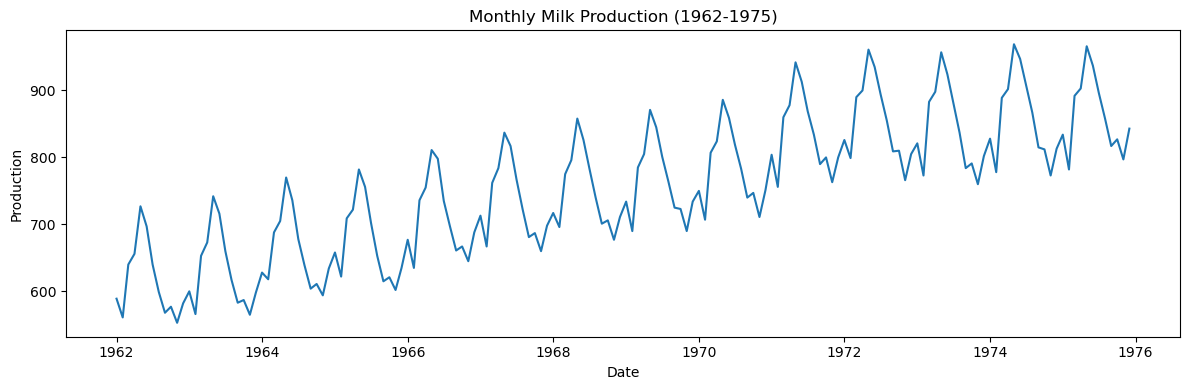

In [5]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Production'])
plt.title('Monthly Milk Production (1962-1975)')
plt.xlabel('Date'); plt.ylabel('Production')
plt.tight_layout()
plt.show()

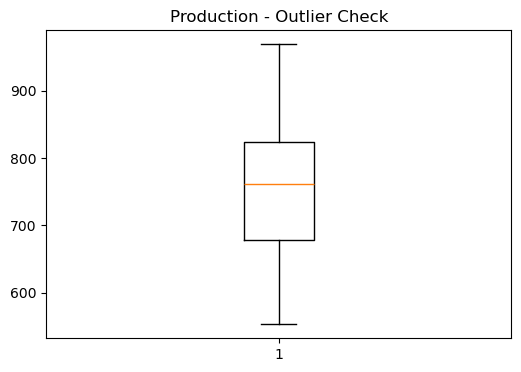

No missing values: True


In [6]:
# Outlier check
plt.figure(figsize=(6,4))
plt.boxplot(df['Production'])
plt.title('Production - Outlier Check')
plt.show()
print('No missing values:', df['Production'].isnull().sum() == 0)

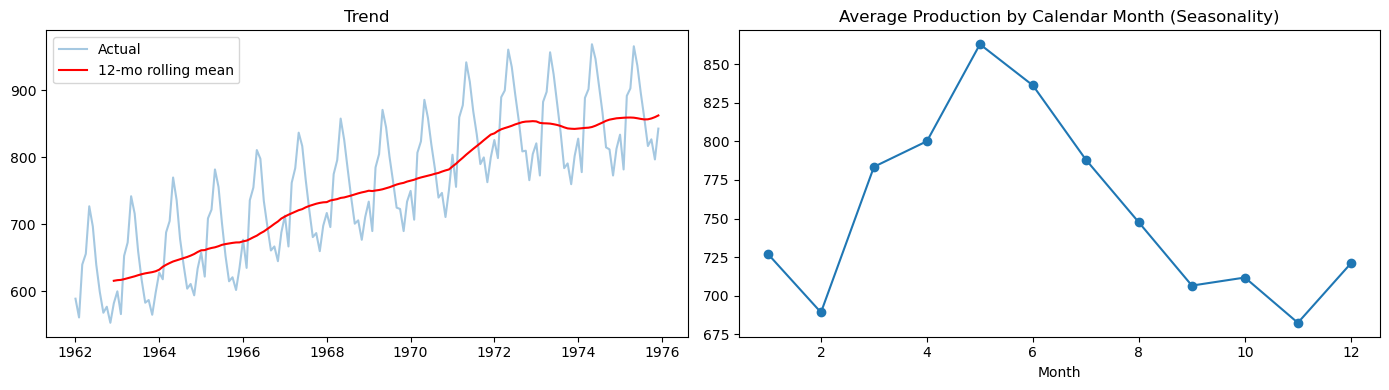

In [7]:
# Trend (12-month rolling mean) and seasonality (avg production by calendar month)
fig, axes = plt.subplots(1, 2, figsize=(14,4))

axes[0].plot(df.index, df['Production'], alpha=0.4, label='Actual')
axes[0].plot(df.index, df['Production'].rolling(12).mean(), label='12-mo rolling mean', color='red')
axes[0].set_title('Trend'); axes[0].legend()

monthly_avg = df.groupby(df.index.month)['Production'].mean()
axes[1].plot(monthly_avg.index, monthly_avg.values, marker='o')
axes[1].set_title('Average Production by Calendar Month (Seasonality)')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

**Observations:** Production shows a clear long-term upward trend plus a repeating annual seasonal pattern (peak around May/June, trough around year-end). No missing values; the boxplot shows no extreme outliers — all values fall within a plausible operating range.

## 2. Data Preparation for Deep Learning

In [8]:
# Scale to [0,1] for neural network training
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Production']])

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW = 12  # 12-month look-back window, matching the annual seasonal cycle
X, y = create_sequences(scaled, WINDOW)
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (156, 12, 1) | y shape: (156, 1)


In [9]:
# Chronological split: 70% train / 15% val / 15% test (no shuffling - time series!)
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)
# Already shaped (samples, timesteps, features=1) - ready for RNN/LSTM/GRU input

Train: (109, 12, 1)  Val: (23, 12, 1)  Test: (24, 12, 1)


## 3. Model Building — RNN, LSTM, GRU

In [ ]:
def build_model(cell_type, units=32, window=WINDOW):
    layer_map = {'RNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layer_map[cell_type](units, activation='tanh'),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

early_stop = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

histories, models = {}, {}
for cell_type in ['RNN', 'LSTM', 'GRU']:
    model = build_model(cell_type, units=32)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200, batch_size=8,
        callbacks=[early_stop], verbose=0
    )
    models[cell_type] = model
    histories[cell_type] = hist
    print(f'{cell_type}: stopped after {len(hist.history["loss"])} epochs, '
          f'val_loss={min(hist.history["val_loss"]):.5f}')

In [ ]:
plt.figure(figsize=(8,4))
for cell_type, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=cell_type)
plt.title('Validation Loss by Model')
plt.xlabel('Epoch'); plt.ylabel('Val MSE (scaled)'); plt.legend()
plt.tight_layout()
plt.show()

**Hyperparameter notes:** window size (12, matching the yearly cycle), hidden units (32), batch size (8, suited to this small dataset), and epochs (up to 200 with early stopping on validation loss) were chosen for a small ~150-sample dataset — small batch size and early stopping reduce overfitting risk. These can be tuned further (e.g. window=6 vs 12, units=16/32/64) but are kept fixed here to compare RNN/LSTM/GRU fairly on identical settings.

## 4. Model Evaluation

In [ ]:
def evaluate(model, X_test, y_test, name):
    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)
    actual = scaler.inverse_transform(y_test)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}, actual, pred

results, preds = [], {}
for cell_type, model in models.items():
    metrics, actual, pred = evaluate(model, X_test, y_test, cell_type)
    results.append(metrics)
    preds[cell_type] = pred

results_df = pd.DataFrame(results)
results_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for ax, cell_type in zip(axes, ['RNN', 'LSTM', 'GRU']):
    ax.plot(actual, label='Actual', marker='o')
    ax.plot(preds[cell_type], label='Predicted', marker='x')
    ax.set_title(cell_type); ax.legend()
plt.suptitle('Predictions vs Actual (Test Set)')
plt.tight_layout()
plt.show()

Compare the MAE/RMSE/MAPE table above: the model with the lowest error values is the best fit for this dataset. LSTM and GRU typically outperform a plain RNN on longer sequences because their gating mechanisms better retain the yearly seasonal pattern, though on a dataset this small the gap can be modest.

## 5. Prediction and Visualization — Next 12 Months

In [ ]:
best_model_name = results_df.sort_values('RMSE').iloc[0]['Model']
best_model = models[best_model_name]
print('Best model:', best_model_name)

# Iteratively forecast the next 12 months using the last known window
last_window = scaled[-WINDOW:].reshape(1, WINDOW, 1)
future_scaled = []
window_input = last_window.copy()

for _ in range(12):
    next_pred = best_model.predict(window_input, verbose=0)
    future_scaled.append(next_pred[0, 0])
    window_input = np.append(window_input[:, 1:, :], [[next_pred[0]]], axis=1)

future = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1))
future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Simple uncertainty band using the test-set residual std of the best model
residual_std = np.std(actual.ravel() - preds[best_model_name].ravel())
lower = future.ravel() - 1.96 * residual_std
upper = future.ravel() + 1.96 * residual_std

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Production'], label='Historical')
plt.plot(future_dates, future, label=f'{best_model_name} Forecast', color='red')
plt.fill_between(future_dates, lower, upper, color='red', alpha=0.2, label='95% interval (approx.)')
plt.title('12-Month Milk Production Forecast')
plt.xlabel('Date'); plt.ylabel('Production'); plt.legend()
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': future.ravel(),
                             'Lower': lower, 'Upper': upper})
forecast_df

## 6. Business Insights

- **Seasonality drives planning:** production consistently peaks in late spring/early summer and dips toward year-end — supply chain, storage, and staffing plans should be built around this recurring cycle, not a flat monthly average.
- **Trend suggests capacity needs:** the multi-year upward trend implies the business should plan for gradually increasing throughput (storage capacity, distribution contracts) rather than static resourcing.
- **Model choice:** the best-performing model (see evaluation table) should be used for operational forecasts; LSTM/GRU are generally preferred over a plain RNN when the forecast horizon needs to capture the full annual cycle.
- **Forecast use:** the 12-month forecast with an uncertainty band can directly inform inventory targets — planning near the upper bound for high-demand months reduces stockout risk, while the lower bound helps avoid overproduction and waste.
- **Caveat:** with only ~14 years of monthly history, forecasts should be refreshed regularly as new data arrives, and treated as directional guidance rather than precise targets, especially further out in the 12-month horizon.